# Virtual Makeup Studio — engineering notes

This notebook walks through how the makeup engine works, the naive baselines it
is benchmarked against, and why the evaluation metrics were chosen the way they
were.

**The engine in one paragraph:** detect MediaPipe's 468-point face mesh, build
soft region masks whose every dimension is a fraction of the interocular
distance (so looks scale with the face), and apply pigment in CIELAB — chroma
moves toward the target shade while lightness keeps the original skin detail.
Lipstick's mask is the outer lip contour *minus the mouth opening*, so teeth
stay clean even mid-smile.

**Why baselines?** Rendering quality claims are easy to fake. So the repo keeps
four deliberately broken implementations (`virtual_makeup.legacy`) — the
classic ways landmark-based AR makeup goes wrong — and scores the engine
against them on 25 real portraits:

1. **Mismatched indices** — dlib's 68-point region numbers applied to the
   468-point mesh: pigment lands on the chin, not the lips.
2. **Opaque fill** — one hard polygon over the whole mouth, fixed-pixel
   eyeshadow offsets, additive compositing.
3. **Channel swap** — `RGB2BGR` applied to an already-BGR image at save time.
4. **Untrained GAN** — a random-weight conv net run in inference.


In [1]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

from virtual_makeup import PRESETS, MakeupLook, apply_makeup, legacy, masks
from virtual_makeup.landmarks import FaceLandmarker

def show(images, titles, height=340):
    fig, axes = plt.subplots(1, len(images), figsize=(2.9 * len(images), 3.4))
    for ax, img, t in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(t, fontsize=10)
        ax.axis("off")
    plt.tight_layout(); plt.show()

astro = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)  # public-domain NASA portrait
landmarker = FaceLandmarker()
mesh = landmarker.detect(astro)
print(f"{len(mesh)} mesh landmarks detected")

468 mesh landmarks detected


I0000 00:00:1784450217.377604 1172367 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1784450217.381563 1172367 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1784450217.488262 1172367 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784450217.493543 1172370 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1784450217.506538 1172369 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 1. The engine vs the baselines, on one portrait


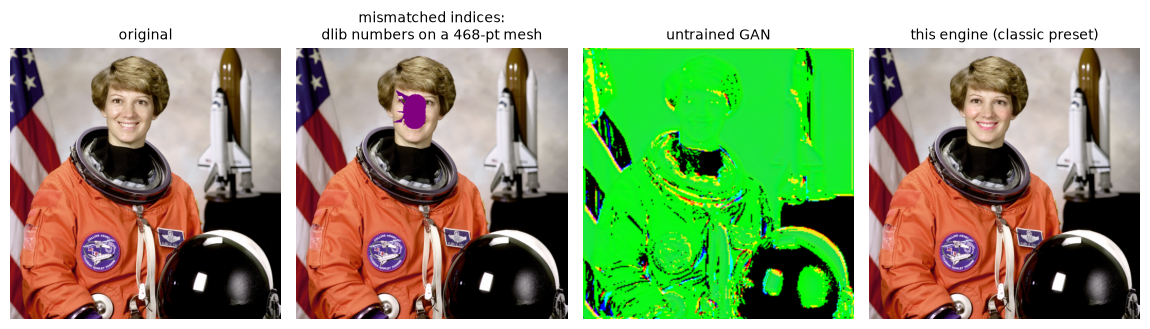

In [2]:
baseline_mp = legacy.legacy_mediapipe(astro, mesh)
gan = cv2.resize(legacy.legacy_gan(astro), astro.shape[1::-1])
engine = apply_makeup(astro, PRESETS["classic"], landmarks=mesh)
show(
    [astro, baseline_mp, gan, engine],
    ["original", "mismatched indices:\ndlib numbers on a 468-pt mesh",
     "untrained GAN", "this engine (classic preset)"],
)

The purple blob near the eye is what mismatched landmark indices produce:
dlib's lip indices 48–59 point at completely different anatomy on MediaPipe's
mesh. Nothing crashes — the pigment just lands on the wrong polygon, which is
why the engine's region sets live in one module (`regions.py`) and are pinned
by tests.

## 2. The channel-swap trap

OpenCV images are BGR. Passing one through `cv2.COLOR_RGB2BGR` "conversion"
before saving doesn't convert anything — it swaps red and blue across the
whole photo. The benchmark keeps this as a baseline because a color-blind
metric (see §5) barely notices it:


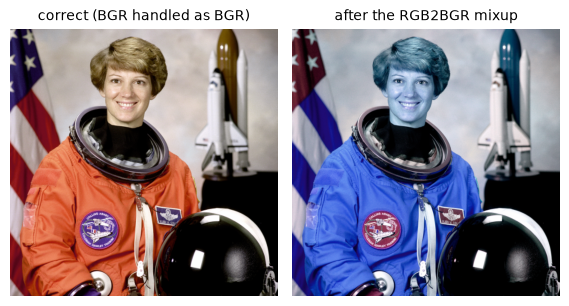

In [3]:
swapped = cv2.cvtColor(astro, cv2.COLOR_RGB2BGR)
show([astro, swapped], ["correct (BGR handled as BGR)", "after the RGB2BGR mixup"])

## 3. How the engine places and applies color

* **Geometry** — canonical FaceMesh index sets for lips (outer *minus inner*
  ring), eyelids, brows, cheeks and the face oval.
* **Placement** — every feather radius, liner thickness and blush axis is a
  fraction of the interocular distance, so the same look survives any image
  resolution (a test doubles the photo and asserts mask areas scale ~4×).
* **Pigment** — CIELAB tinting: chroma moves toward the shade, lightness keeps
  most of the original detail, so pores and lip creases survive.


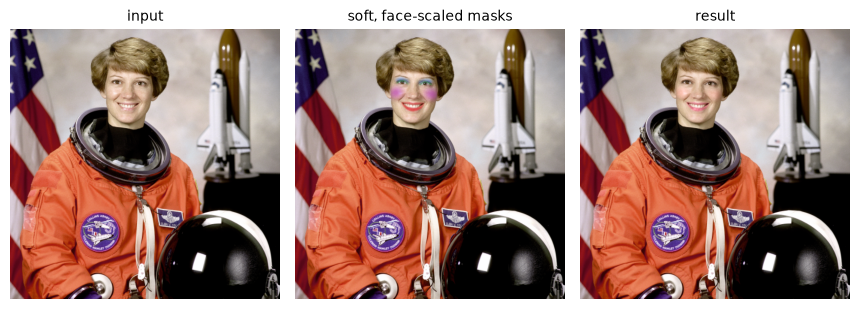

In [4]:
shape = astro.shape[:2]
overlay = astro.astype(np.float32)
for color, fn in [((60, 60, 220), masks.lip_mask), ((200, 120, 60), masks.eyeshadow_mask),
                  ((60, 200, 60), masks.eyeliner_mask), ((180, 60, 180), masks.blush_mask)]:
    m = fn(mesh, shape)[..., None]
    overlay = overlay * (1 - 0.85 * m) + np.array(color) * 0.85 * m
show([astro, overlay.astype(np.uint8), engine],
     ["input", "soft, face-scaled masks", "result"])

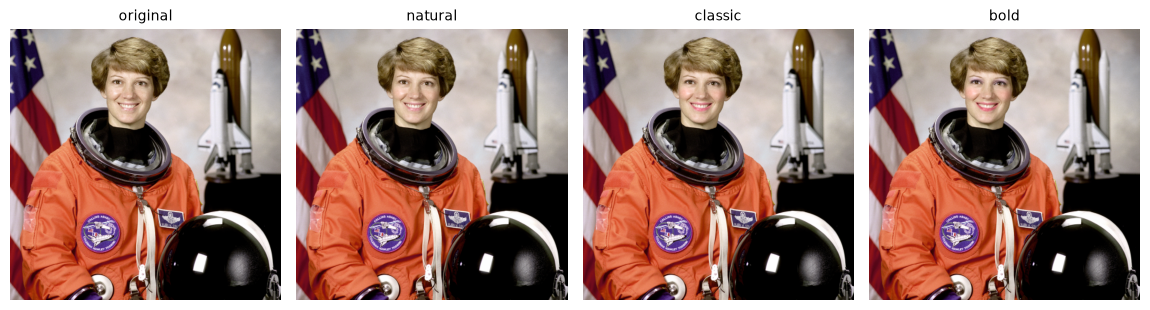

In [5]:
looks = [("natural", PRESETS["natural"]), ("classic", PRESETS["classic"]), ("bold", PRESETS["bold"])]
show([astro] + [apply_makeup(astro, lk, landmarks=mesh) for _, lk in looks],
     ["original"] + [name for name, _ in looks])

## 4. Benchmark — every method, 25 real photos

`scripts/benchmark.py` runs the engine and all four baselines on the no-makeup
half of a paired makeup dataset, scoring:

* **containment** — share of edit energy inside legitimate makeup regions
* **background integrity** — background pixels left bit-identical
* **lip texture** — correlation of lip lightness before/after
* **identity SSIM** — the output should still be the same photo


In [6]:
bench = json.loads((Path.cwd().parent / "reports" / "benchmark.json").read_text())
summary = bench["summary"]
NAMES = {"legacy_mediapipe": "mismatched indices", "legacy_dlib": "opaque fill",
         "legacy_dlib_swap": "channel swap", "legacy_gan": "untrained GAN",
         "new_classic": "this engine"}

import pandas as pd
rows = []
for method, s in summary.items():
    rows.append({
        "method": NAMES[method],
        "containment": round(s["containment"]["mean"], 3),
        "background": round(s["background_integrity"]["mean"], 3),
        "lip texture": round(s["lip_texture_corr"]["mean"], 3),
        "identity SSIM": round(s["identity_ssim"]["mean"], 3),
        "ms/image": round(s["runtime_ms"], 1),
    })
pd.DataFrame(rows).set_index("method")

,containment,background,lip texture,identity SSIM,ms/image
method,,,,,
mismatched indices,0.337,1.000,0.811,0.976,7.4
opaque fill,0.791,1.000,0.865,0.997,12.8
channel swap,0.140,0.017,0.908,0.993,12.4
untrained GAN,0.089,0.000,-0.205,0.586,41.2
this engine,0.825,1.000,0.996,0.998,285.2


The engine's containment is 0.825 rather than 1.0 only because the metric is
strict: the remaining energy is invisible ±1–2-count ripple in the feathered
falloff. At any non-zero mask threshold the engine's containment is exactly
1.0 by construction — it cannot write outside its masks, and the test suite
asserts the background stays bit-identical.

## 5. Why the metrics look like this (and not "SSIM vs a reference")

A tempting way to score makeup transfer is grayscale SSIM against a reference
with-makeup photo, plus a threshold "accuracy". Running that protocol on every
method shows why it was rejected:


In [7]:
protocol = bench["original_protocol_reproduction"]
rows = []
for method, p in protocol.items():
    m = p["legacy_metrics@0.45"]
    rows.append({
        "method": NAMES[method],
        "SSIM vs reference": round(p["mean_ssim_vs_reference"], 3),
        "\u201caccuracy\u201d": round(m["Accuracy"], 3),
        "\u201cprecision\u201d": m["Precision"],
    })
pd.DataFrame(rows).set_index("method")

,SSIM vs reference,“accuracy”,“precision”
method,,,
mismatched indices,0.520,0.68,1.0
opaque fill,0.530,0.88,1.0
channel swap,0.527,0.80,1.0
untrained GAN,0.378,0.24,1.0
this engine,0.531,0.88,1.0


Two failure modes, both fatal:

1. **The metric cannot distinguish working code from broken code.** The
   channel-swapped blue face scores 0.527 — statistically identical to the
   engine's 0.531 — because grayscale SSIM is blind to color, and makeup *is*
   color.
2. **"Precision = 1.0" is an artifact.** With `y_true` all ones, precision is
   1.0 for every method, including untrained noise. A metric that a known-broken
   baseline can pass measures nothing.

That is why the benchmark scores *where the pigment landed* and *what survived*
instead — metrics the baselines demonstrably fail.

## 6. Takeaways

* Landmark index sets are a contract with a specific topology; mixing two
  topologies fails silently and visibly at once. Pin them with tests.
* Never ship a metric a broken baseline can pass — keep the broken baselines
  around and check.
* Makeup rendering is a color-space problem: recolor chroma in CIELAB, leave
  lightness mostly alone, and skin stops looking like paint.
